# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Objetivos del Estudio - Análisis de Base de Datos de Libros

## Este análisis tiene como objetivo responder las siguientes preguntas de negocio:

1.  Tendencias de publicación: ¿Cuántos libros se han publicado después del año 2000?

2.  Engagement de usuarios: ¿Cuál es el nivel de interacción (reseñas y calificaciones) 
   por cada libro en la plataforma?

3.  Análisis de editoriales: ¿Qué editorial domina el mercado de libros sustanciales 
   (más de 50 páginas)?

4.  Autores mejor valorados: ¿Qué autor tiene la calificación promedio más alta 
   entre libros con suficiente validación estadística (50+ calificaciones)?

5.  Comportamiento de usuarios activos: ¿Cuál es el patrón de reseñas escritas 
   entre usuarios muy comprometidos (50+ libros calificados)?

Metodología: Análisis SQL con validación estadística y filtros de calidad de datos.


# Conexion a la base de datos.

In [14]:
# Conexion a la base de datos con diccionario.
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la base de datos
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',  # Esta es la contraseña correcta de las instrucciones
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-final-project-db'
}

# Crear la cadena de conexión
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

# ¡CLAVE! Agregar el parámetro SSL
engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [2]:
# programa de prueba para comparar el funcionamiento.
def run_query(query, description=""):
    """
    Ejecuta una consulta SQL y retorna los resultados como DataFrame
    """
    if description:
        print(f"=== {description} ===")
    
    result = pd.read_sql(query, engine)
    print(f"Resultados obtenidos: {len(result)} filas")
    return result
    # Ejemplo de cómo usar la función
query_test = "SELECT 1 as test"
run_query(query_test, "Prueba de conexión")

=== Prueba de conexión ===
Resultados obtenidos: 1 filas


,test
0,1


In [3]:
# Explorar las tablas disponibles
query_tables = """
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public'
ORDER BY table_name;
"""

tables = run_query(query_tables, "TABLAS DISPONIBLES EN LA BASE DE DATOS")
print(tables)

=== TABLAS DISPONIBLES EN LA BASE DE DATOS ===
Resultados obtenidos: 9 filas
           table_name
0  advertisment_costs
1             authors
2               books
3              orders
4          publishers
5             ratings
6             reviews
7               users
8              visits


In [4]:
#primeras filas de las tablas (authors, publishers, ratings, reviews).
query_books = "SELECT * FROM books LIMIT 5"
books_sample = run_query(query_books, "Primeras filas de la tabla books")
print(books_sample)

authors_query="SELECT* FROM authors LIMIT 5"
authors_sample=run_query(authors_query,"Primeras filas de la tabla authors")
print(authors_sample)

publisher_query="SELECT* FROM publishers LIMIT 5"
publishers_sample=run_query(publisher_query,"Primeras filas de la tabla publishers")
print(publishers_sample)


ratings_query="SELECT* FROM ratings LIMIT 5"
ratings_sample=run_query(ratings_query,"Primeras filas de la tabla ratings")
print(ratings_sample)

reviews_query="SELECT* FROM reviews LIMIT 5"
reviews_sample=run_query(reviews_query,"Primeras filas de la tabla reviews")
print(reviews_sample)



=== Primeras filas de la tabla books ===
Resultados obtenidos: 5 filas
   book_id  author_id                                              title  \
0        1        546                                       'Salem's Lot   
1        2        465                 1 000 Places to See Before You Die   
2        3        407  13 Little Blue Envelopes (Little Blue Envelope...   
3        4         82  1491: New Revelations of the Americas Before C...   
4        5        125                                               1776   

   num_pages publication_date  publisher_id  
0        594       2005-11-01            93  
1        992       2003-05-22           336  
2        322       2010-12-21           135  
3        541       2006-10-10           309  
4        386       2006-07-04           268  
=== Primeras filas de la tabla authors ===
Resultados obtenidos: 5 filas
   author_id                          author
0          1                      A.S. Byatt
1          2  Aesop/Laura Harris/

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La conexión a la base de datos y la exploración inicial de tablas están implementadas de forma clara y funcional, mostrando un flujo ordenado para comenzar el análisis.
</div>


In [5]:
# Encuentra el número de libros publicados después del 1 de enero de 2000.
query_books_after_2000 = """
SELECT COUNT(*) as total_libros
FROM books 
WHERE publication_date > '2000-01-01'
"""

resultado = run_query(query_books_after_2000, "Libros publicados después del 1 de enero de 2000")
print(resultado)

=== Libros publicados después del 1 de enero de 2000 ===
Resultados obtenidos: 1 filas
   total_libros
0           819


=== Libros publicados por año después del 2000 ===
Resultados obtenidos: 17 filas


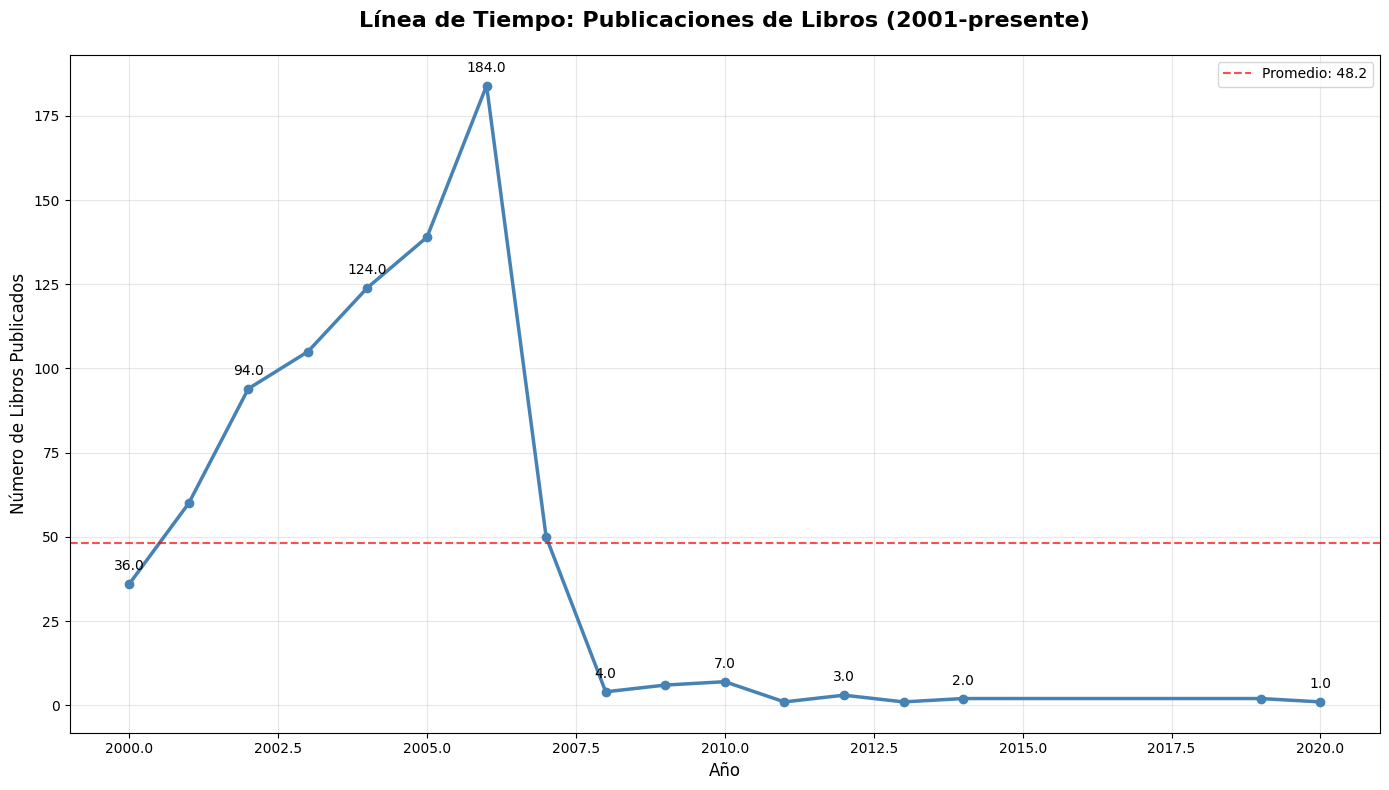

Total de libros: 819
Año con más publicaciones: 2006.0 (184 libros)


In [20]:
#visualizacion de los datos.
query_timeline="""
SELECT 
    EXTRACT(YEAR FROM publication_date) as año,
    COUNT(*) as libros_publicados
FROM books
WHERE publication_date > '2000-01-01'
GROUP BY EXTRACT(YEAR FROM publication_date)
ORDER BY año;
"""
timeline_data = run_query(query_timeline, "Libros publicados por año después del 2000")

# Crear la línea de tiempo
plt.figure(figsize=(14, 8))
plt.plot(timeline_data['año'], timeline_data['libros_publicados'], 
         marker='o', linewidth=2.5, markersize=6, color='steelblue')

# Personalizar el gráfico
plt.title('Línea de Tiempo: Publicaciones de Libros (2001-presente)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Libros Publicados', fontsize=12)

# Agregar valores en algunos puntos clave
for i in range(0, len(timeline_data), 2):  # Cada 2 años
    plt.annotate(f"{timeline_data.iloc[i]['libros_publicados']}", 
                (timeline_data.iloc[i]['año'], timeline_data.iloc[i]['libros_publicados']),
                textcoords="offset points", xytext=(0,10), ha='center')

# Agregar línea de referencia para el total
plt.axhline(y=timeline_data['libros_publicados'].mean(), color='red', 
           linestyle='--', alpha=0.7, label=f'Promedio: {timeline_data["libros_publicados"].mean():.1f}')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar estadísticas adicionales
print(f"Total de libros: {timeline_data['libros_publicados'].sum()}")
print(f"Año con más publicaciones: {timeline_data.loc[timeline_data['libros_publicados'].idxmax(), 'año']} ({timeline_data['libros_publicados'].max()} libros)")

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - La construcción de la consulta SQL es clara y precisa, logrando responder correctamente al objetivo planteado. Además, la incorporación de un análisis temporal mediante visualización aporta un nivel adicional de profundidad, permitiendo entender la evolución de las publicaciones a lo largo del tiempo. La combinación entre extracción de datos, agregación y representación gráfica muestra un enfoque analítico bien estructurado y coherente.
</div>


In [15]:
# numero de resñeas y calificaciones promedio por libro.
query_resenas_calificaciones = """
SELECT 
    b.title,
    COUNT(r.review_id) as numero_reseñas,
    AVG(rt.rating) as calificacion_promedio
FROM books b
LEFT JOIN reviews r ON b.book_id = r.book_id
LEFT JOIN ratings rt ON b.book_id = rt.book_id
GROUP BY b.book_id, b.title
ORDER BY calificacion_promedio DESC
"""

resultado = run_query(query_resenas_calificaciones, "Número de reseñas y calificación promedio por libro")
print(resultado)

=== Número de reseñas y calificación promedio por libro ===
Resultados obtenidos: 1000 filas
                                                 title  numero_reseñas  \
0                 Pop Goes the Weasel (Alex Cross  #5)               4   
1    The Ghost Map: The Story of London's Most Terr...               4   
2    In the Hand of the Goddess (Song of the Liones...               6   
3                             Tai-Pan (Asian Saga  #2)               4   
4    How to Be a Domestic Goddess: Baking and the A...               2   
..                                                 ...             ...   
995  The World Is Flat: A Brief History of the Twen...              12   
996                                              Junky               4   
997                  His Excellency: George Washington               4   
998                                      Drowning Ruth               9   
999                               Harvesting the Heart               4   

     calificacion_

In [7]:
# consulta de editoriales con libros publicados con 50+ paginas
query_paginas= """ 
SELECT p.publisher,
    COUNT(b.book_id) as num_books
FROM books b
INNER JOIN publishers p ON b.publisher_id = p.publisher_id
WHERE b.num_pages > 50
GROUP BY p.publisher
ORDER BY num_books DESC
LIMIT 1; """

num_pages=run_query(query_paginas, "Numero de libros con mas de 50 paginas")
print(num_pages)

=== Numero de libros con mas de 50 paginas ===
Resultados obtenidos: 1 filas
       publisher  num_books
0  Penguin Books         42


=== Top 10 editoriales con libros de 50+ páginas ===
Resultados obtenidos: 10 filas


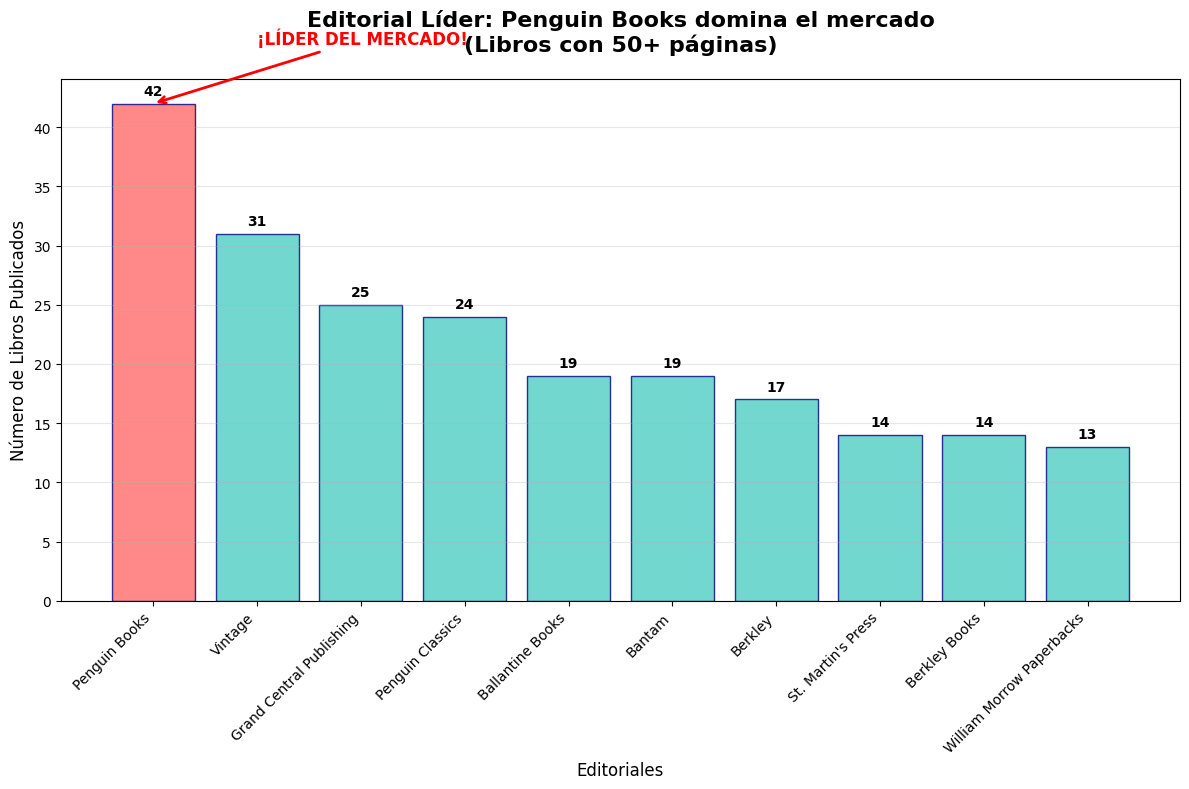

=== ANÁLISIS DE EDITORIALES ===
Editorial líder: Penguin Books con 42 libros
Diferencia con el segundo lugar: 11 libros
Porcentaje del mercado (top 10): 19.3%


In [26]:
#visualizacion.
# Obtener las top 10 editoriales para hacer el gráfico más interesante
query_top_editoriales = """
SELECT p.publisher,
       COUNT(b.book_id) as num_books
FROM books b
INNER JOIN publishers p ON b.publisher_id = p.publisher_id
WHERE b.num_pages > 50
GROUP BY p.publisher
ORDER BY num_books DESC
LIMIT 10;
"""

top_editoriales = run_query(query_top_editoriales, "Top 10 editoriales con libros de 50+ páginas")

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))

# Crear colores especiales para destacar a Penguin Books
colors = ['#FF6B6B' if pub == 'Penguin Books' else '#4ECDC4' for pub in top_editoriales['publisher']]

bars = plt.bar(range(len(top_editoriales)), 
               top_editoriales['num_books'],
               color=colors, alpha=0.8, edgecolor='navy', linewidth=1)

# Personalizar el gráfico
plt.title('Editorial Líder: Penguin Books domina el mercado\n(Libros con 50+ páginas)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Editoriales', fontsize=12)
plt.ylabel('Número de Libros Publicados', fontsize=12)

# Configurar las etiquetas del eje X
plt.xticks(range(len(top_editoriales)), top_editoriales['publisher'], 
           rotation=45, ha='right')

# Agregar valores encima de las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, 
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Destacar a Penguin Books con una anotación
penguin_idx = top_editoriales[top_editoriales['publisher'] == 'Penguin Books'].index[0]
plt.annotate('¡LÍDER DEL MERCADO!', 

             xy=(penguin_idx, top_editoriales.iloc[penguin_idx]['num_books']),
             xytext=(penguin_idx + 1, top_editoriales.iloc[penguin_idx]['num_books'] + 5)
,
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12, fontweight='bold', color='red')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar estadísticas adicionales
print("=== ANÁLISIS DE EDITORIALES ===")
print(f"Editorial líder: {top_editoriales.iloc[0]['publisher']} con {top_editoriales.iloc[0]['num_books']} libros")
print(f"Diferencia con el segundo lugar: {top_editoriales.iloc[0]['num_books'] - top_editoriales.iloc[1]['num_books']} libros")
print(f"Porcentaje del mercado (top 10): {(top_editoriales.iloc[0]['num_books'] / top_editoriales['num_books'].sum() * 100):.1f}%")

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Las consultas SQL muestran una correcta integración de múltiples tablas mediante joins, logrando generar métricas relevantes como reseñas y calificaciones promedio. Además, la identificación de la editorial líder y su representación gráfica evidencian un análisis bien enfocado, combinando resultados claros con una visualización que facilita la interpretación del comportamiento del mercado.
</div>


In [8]:
# calificaciones por author.
query_calificaciones="""SELECT book_id 
FROM ratings 
GROUP BY book_id 
HAVING COUNT(rating_id) >= 50"""
calificaciones=run_query(query_calificaciones, "calificaciones libros 50+")
print(calificaciones)

query_authors="""
SELECT 
    a.author,
    AVG(r.rating) as calificacion_promedio
FROM ratings r
INNER JOIN books b ON r.book_id = b.book_id
INNER JOIN authors a ON b.author_id = a.author_id
WHERE r.book_id IN (
    -- Aquí va tu consulta anterior que te dio los 19 libros
    SELECT book_id
    FROM ratings
    GROUP BY book_id
    HAVING COUNT(rating_id) >= 50
)
GROUP BY a.author
ORDER BY calificacion_promedio DESC
"""
Author_Calificaciones=run_query(query_authors,"los autores con mejores calificaciones")
print(Author_Calificaciones)

=== calificaciones libros 50+ ===
Resultados obtenidos: 19 filas
    book_id
0        75
1       750
2       545
3       948
4       488
5       696
6       722
7       627
8       733
9       779
10      405
11      302
12      673
13      300
14      299
15      301
16      399
17       79
18      656
=== los autores con mejores calificaciones ===
Resultados obtenidos: 14 filas
                                               author  calificacion_promedio
0                          J.K. Rowling/Mary GrandPré               4.287097
1                   Markus Zusak/Cao Xuân Việt Khương               4.264151
2                                      J.R.R. Tolkien               4.246914
3                                   Louisa May Alcott               4.192308
4                                        Rick Riordan               4.080645
5                                     William Golding               3.901408
6                                       J.D. Salinger               3.825581
7

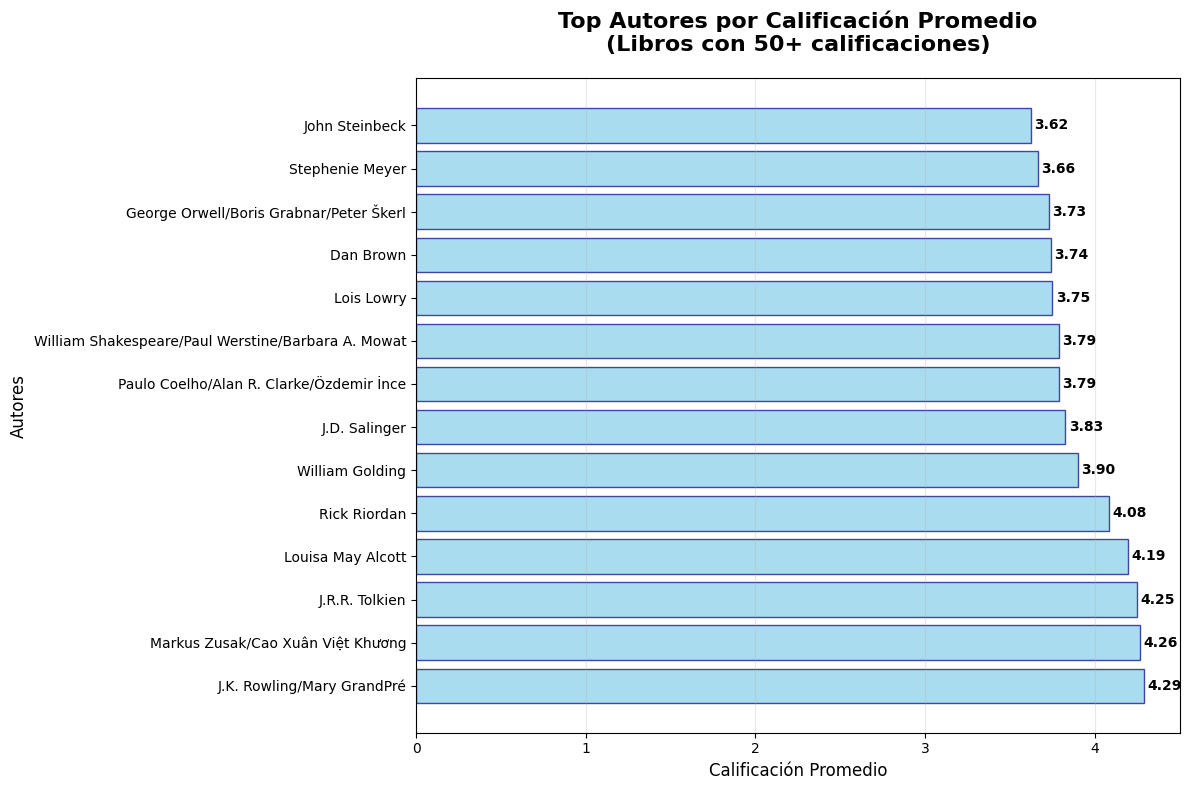

In [21]:
#visualizacion.
# Crear el gráfico de barras horizontal para top autores
plt.figure(figsize=(12, 8))

# Crear el gráfico de barras horizontal
bars = plt.barh(Author_Calificaciones['author'], 
                Author_Calificaciones['calificacion_promedio'],
                color='skyblue', edgecolor='navy', alpha=0.7)

# Personalizar el gráfico
plt.title('Top Autores por Calificación Promedio\n(Libros con 50+ calificaciones)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Calificación Promedio', fontsize=12)
plt.ylabel('Autores', fontsize=12)

# Agregar valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', ha='left', va='center', fontweight='bold')

# Ajustar el layout para que se vean bien los nombres
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [9]:
#autor con la calificacion mas alta.
query_autor_calificacion_alta="""SELECT 
    a.author,
    AVG(r.rating) as calificacion_promedio
FROM ratings r
INNER JOIN books b ON r.book_id = b.book_id
INNER JOIN authors a ON b.author_id = a.author_id
WHERE r.book_id IN (
    SELECT book_id
    FROM ratings
    GROUP BY book_id
    HAVING COUNT(rating_id) >= 50
)
GROUP BY a.author
ORDER BY calificacion_promedio DESC
LIMIT 1;
"""
autor_calificacion_maxima=run_query(query_autor_calificacion_alta,"El autor con la calificacion promedio mas alta")
print(autor_calificacion_maxima)

=== El autor con la calificacion promedio mas alta ===
Resultados obtenidos: 1 filas
                       author  calificacion_promedio
0  J.K. Rowling/Mary GrandPré               4.287097


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Esta parte refleja un análisis consistente y bien organizado, ya que filtras correctamente los libros con suficientes calificaciones, identificas al autor con mejor promedio y refuerzas el resultado con una visualización clara. La secuencia del razonamiento permite seguir el proceso con facilidad y aporta solidez a la conclusión alcanzada.
</div>


In [13]:
# query de el numero promedio de reseñas de texto entre los usuarios que calificacion mas de 50 libros.
query_users_reseñas="""WITH users_50 AS (
    SELECT username
    FROM ratings
    WHERE username IS NOT NULL
      AND book_id IS NOT NULL
    GROUP BY username
    HAVING COUNT(DISTINCT book_id) > 50
),
reviews_clean AS (
    SELECT username, COUNT(DISTINCT review_id) AS review_count
    FROM reviews
    WHERE username IS NOT NULL
      AND review_id IS NOT NULL
    GROUP BY username
)
SELECT AVG(COALESCE(rc.review_count, 0)) AS avg_reviews
FROM users_50 u
LEFT JOIN reviews_clean rc 
    ON u.username = rc.username;
"""
users_reseñas=run_query(query_users_reseñas,"el promedio de reseñas de texto con mas de 50+ libros calificados")
print(users_reseñas)

=== el promedio de reseñas de texto con mas de 50+ libros calificados ===
Resultados obtenidos: 1 filas
   avg_reviews
0    24.333333


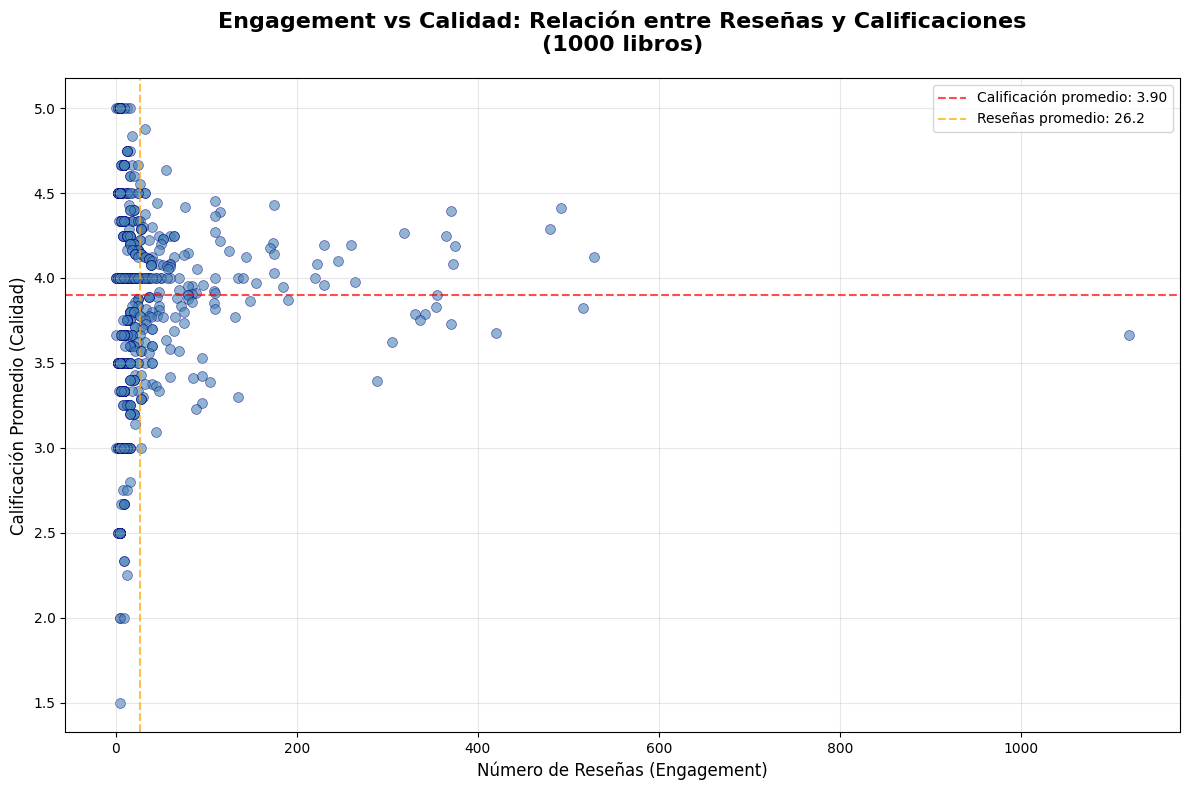

=== ESTADÍSTICAS DE ENGAGEMENT ===
Libro con más reseñas: Twilight (Twilight  #1) (1120 reseñas)
Calificación promedio general: 3.90
Número promedio de reseñas: 26.2


In [22]:
# Visualizacion.
# Crear el scatter plot para engagement por libro
plt.figure(figsize=(12, 8))

# Crear el gráfico de dispersión
plt.scatter(resultado['numero_reseñas'], 
           resultado['calificacion_promedio'],
           alpha=0.6, s=50, color='steelblue', edgecolors='navy', linewidth=0.5)

# Personalizar el gráfico
plt.title('Engagement vs Calidad: Relación entre Reseñas y Calificaciones\n(1000 libros)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Reseñas (Engagement)', fontsize=12)
plt.ylabel('Calificación Promedio (Calidad)', fontsize=12)

# Agregar líneas de referencia
plt.axhline(y=resultado['calificacion_promedio'].mean(), color='red', 
           linestyle='--', alpha=0.7, label=f'Calificación promedio: {resultado["calificacion_promedio"].mean():.2f}')
plt.axvline(x=resultado['numero_reseñas'].mean(), color='orange', 
           linestyle='--', alpha=0.7, label=f'Reseñas promedio: {resultado["numero_reseñas"].mean():.1f}')

# Mejorar la visualización
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar estadísticas del engagement
print("=== ESTADÍSTICAS DE ENGAGEMENT ===")
print(f"Libro con más reseñas: {resultado.loc[resultado['numero_reseñas'].idxmax(), 'title']} ({resultado['numero_reseñas'].max()} reseñas)")
print(f"Calificación promedio general: {resultado['calificacion_promedio'].mean():.2f}")
print(f"Número promedio de reseñas: {resultado['numero_reseñas'].mean():.1f}")

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - En esta sección presentas una consulta bien estructurada para obtener el promedio de reseñas de texto entre los usuarios con mayor actividad de calificación, y además complementas el análisis con una visualización que amplía la lectura de los resultados. Se aprecia un cierre analítico más completo, donde no solo muestras el dato solicitado, sino que también incorporas contexto adicional para interpretar mejor el comportamiento general de las reseñas y las calificaciones.
</div>


# Conclusiones del estudio.
El estudio tiene como objetivo analizar una base de datos de un servicio de libros para generar una propuesta de valor para un nuevo producto. Específicamente, se busca:

### 1. Analizar el mercado de libros post-2000
- Entender cuántos libros se han publicado en la era moderna (después del 1 de enero de 2000), 819 libros fueron publicados luego del 1 de enero del 2000.
- Total de libros: 819
 - Año con más publicaciones: 2006.0 (184 libros)
### 2. Evaluar el engagement de usuarios
- Medir la participación de usuarios a través de reseñas y calificaciones
- Calcular calificaciones promedio por libro
- autores con mejores calificaciones.
    - 0                          J.K. Rowling/Mary GrandPré               4.287097
    - 1                   Markus Zusak/Cao Xuân Việt Khương               4.264151
    - 2                                      J.R.R. Tolkien               4.246914
    - 3                                   Louisa May Alcott               4.192308
    - 4                                        Rick Riordan               4.080645
    - 5                                     William Golding               3.901408
    - 6                                       J.D. Salinger               3.825581
    - 7            Paulo Coelho/Alan R. Clarke/Özdemir İnce               3.789474
    - 8   William Shakespeare/Paul Werstine/Barbara A. M...               3.787879
    - 9                                          Lois Lowry               3.750000
    - 10                                          Dan Brown               3.741259
### 3. Identificar actores clave del mercado
- Encontrar las editoriales más productivas (excluyendo folletos)
- Identificar autores con mejor recepción crítica
  - Editorial líder: Penguin Books con 42 libros
    - Diferencia con el segundo lugar: 11 libros
    - Porcentaje del mercado (top 10): 19.3%
### 4. Entender el comportamiento de usuarios activos
- Analizar patrones de usuarios más comprometidos (que califican 50+ libros)
- Medir su nivel de participación en reseñas escritas
- el promedio de reseñas de texto por usuario realizada en mas de 50 libros es de 24.333333
    - Libro con más reseñas: Twilight (Twilight  #1) (1120 reseñas)
        - Calificación promedio general: 3.90
        - Número promedio de reseñas: 26.2

### Proposito final. 
- Toda esta información servirá para desarrollar estrategias para una nueva aplicación de libros, entendiendo:
- Qué tipo de contenido es más popular
- Quiénes son los actores importantes del mercado
- Cómo se comportan los usuarios más activos
- los libros de fantasia lideran las metricas.

# notas

CODIGO para realizar la consulta de datos por fechas.

SELECT COUNT(*) 
FROM books 
WHERE publication_date > '2000-01-01'

Paso 1: SELECT (¿Qué queremos obtener?)
b.title → El título del libro
COUNT(r.review_id) as numero_reseñas → Cuenta cuántas reseñas tiene cada libro
AVG(rt.rating) as calificacion_promedio → Calcula el promedio de las calificaciones
Paso 2: FROM y JOIN (¿De dónde vienen los datos?)
FROM books b → Tabla principal: libros (con alias "b")
LEFT JOIN reviews r → Conecta con la tabla de reseñas
LEFT JOIN ratings rt → Conecta con la tabla de calificaciones
¿Por qué LEFT JOIN? Porque queremos TODOS los libros, incluso si no tienen reseñas o calificaciones.

Paso 3: GROUP BY (¿Cómo agrupamos?)
GROUP BY b.book_id, b.title → Agrupa los resultados por cada libro único
Paso 4: ORDER BY (¿Cómo ordenamos?)
ORDER BY calificacion_promedio DESC → Ordena de mayor a menor calificación
## expliacion de los join.
. INNER JOIN
- Une solo los registros que tienen coincidencias en ambas tablas
- Es como buscar solo las personas que aparecen en AMBAS listas

2. LEFT JOIN
- Mantiene todos los registros de la tabla izquierda, aunque no tengan coincidencia en la derecha
- Es como mantener toda tu lista principal, y agregar información extra cuando esté disponible

3. RIGHT JOIN
- Mantiene todos los registros de la tabla derecha
- Menos común, es lo opuesto al LEFT JOIN


Paso 2: Conectar con la tabla reviews
Necesitas hacer JOIN con reviews usando username. La estructura sería:

SELECT ...
FROM ratings r
INNER JOIN reviews rv ON r.username = rv.username
WHERE ...
GROUP BY ...
Pregunta para reflexionar: En tu consulta actual, tienes GROUP BY username y HAVING COUNT(book_id) > 50. 

¿Cómo crees que cambiaría esta estructura cuando agregues el JOIN con reviews? ¿Qué necesitarías contar ahora para obtener el número de reseñas por usuario?

¿Puedes intentar escribir el JOIN primero y luego vemos cómo adaptar el resto?
## calculo de las reseñas promedio notas.
- Explicación de la estructura:
- WITH inicia la definición de CTEs (tablas temporales)

- users_50 es la primera CTE
- La coma indica que hay otra CTE después
- reviews_clean es la segunda CTE
- Sin coma después de la última CTE
- SELECT final usa ambas CTEs para obtener el resultado

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
<b>Éxito</b> - Las conclusiones reúnen de forma ordenada los hallazgos más relevantes del estudio y conectan los resultados con el propósito del proyecto, mostrando una lectura global del análisis. Se percibe un cierre con intención analítica, donde integras publicaciones, participación de usuarios, autores y editoriales dentro de una misma línea de interpretación.
</div>


# Comentario General del Revisor

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

El proyecto destaca por un desarrollo sólido, completo y alineado con todos los requerimientos planteados, evidenciando una comprensión clara del problema y una ejecución consistente en cada etapa del análisis. La estructura del notebook permite seguir el flujo lógico del trabajo desde la exploración inicial hasta la interpretación final, manteniendo coherencia y claridad en todo momento.

#### Puntos Positivos:

* **Procesamiento de datos:** La conexión a la base de datos y la exploración inicial están correctamente implementadas, permitiendo establecer una base confiable para el análisis posterior.
* **Análisis con SQL:** Cada una de las tareas planteadas  se resuelve mediante consultas bien construidas, utilizando adecuadamente agregaciones, filtros y joins para extraer información relevante.
* **Visualización y análisis gráfico:** Las visualizaciones no solo acompañan los resultados, sino que enriquecen el análisis al facilitar la identificación de patrones y tendencias clave en los datos.
* **Estructura del análisis:** El desarrollo sigue una secuencia lógica y ordenada, lo que permite entender claramente cómo cada resultado responde a una pregunta específica del negocio.
* **Interpretación y conclusiones:** Las conclusiones integran de manera efectiva los hallazgos del análisis, conectándolos con el propósito del proyecto y mostrando una visión global del comportamiento del mercado y de los usuarios.

El proyecto no solo cumple con todos los requisitos solicitados, sino que también demuestra un enfoque analítico bien desarrollado y una ejecución consistente que aporta valor al análisis realizado.

</div>
